In [1]:
from IPython.display import display, HTML

display(HTML(r"""
<style>
/* JupyterLab 4.x: center the notebook area */
.jp-NotebookPanel-notebook,
.jp-NotebookPanel .jp-Notebook {
  width: 85% !important;
  max-width: 1100px !important;
  margin: 0 auto !important;
}

/* Make wide outputs scroll instead of breaking the layout */
.jp-OutputArea-output {
  overflow-x: auto !important;
}
</style>
"""))

%config InlineBackend.figure_format = "svg"
print("Centered JupyterLab notebook + SVG inline figures.")

Centered JupyterLab notebook + SVG inline figures.


### Lecture-04: Neural language models

- **CS40008.01, NLP and LLMs**
- **Date:** 03/19/2026
- **Lecturer:** Baojian Zhou
- **Institution:** The School of Data Science, Fudan University

<a id="0"></a> <br>
### Table of Contents
- [1. PyTorch introduction](#1)
  - [1.1 Tensors](#11)
  - [1.2 Operations](#12)
  - [1.3 Torch/Numpy Converting](#13)
  - [1.4 Autograd](#14)
  - [1.5 Gradients](#15)
- [2. micrograd](#2)
  - [2.1 Value](#21)
  - [2.2 Module and Neuron](#22)
  - [2.3 Value/Neuron Operations](#23)
- [3. NPLM](#3)
  - [3.1 Pytorch NPLM](#31)
  - [3.2 NPLM on tiny dataset](#32)
  - [3.3 NPLM on wikitext dataset](#33)
- [4. LSTM](#4)
  - [4.1 Pytorch LSTM](#41)
  - [4.2 Training LSTM](#42)

In [2]:
import time
from detect_torch_device import detect_torch_device
device = detect_torch_device()
jnk_start_time = time.time()

[HAMI-core Msg(181148:139950633479040:libvgpu.c:837)]: Initializing.....
[HAMI-core Warn(181148:139950633479040:multiprocess_memory_limit.c:552)]: Kick dead proc 103380


numpy: 2.4.3
torch: 2.11.0+cu130
cuda devices: 1
  [0] NVIDIA A100-SXM4-80GB


[HAMI-core Msg(181148:139950633479040:libvgpu.c:853)]: Initialized


<a id="1"></a>
### 1. PyTorch introduction

The following tutorial is adopted from:

https://brsoff.github.io/tutorials/beginner/deep_learning_60min_blitz.html

**WHAT IS PYTORCH?**

>It’s a Python-based scientific computing package targeted at two sets of audiences:
> 1. A replacement for NumPy to use the power of GPUs
> 2. a deep learning research platform that provides maximum flexibility and speed

<a id="11"></a>
#### 1.1 Tensors

In [3]:
from __future__ import print_function
import torch
import numpy as np

- Task-01 Construct a 5x3 matrix, uninitialized:

In [4]:
x = torch.empty(5, 4)
print(x)

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 1.4412e+17,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  2.0319e-43,  0.0000e+00],
        [-7.6834e-36,  3.0957e-41, -1.9449e-35,  3.0957e-41]])


In [5]:
# Task-02 Construct a randomly initialized matrix:
x = torch.rand(5,4)
print(x)

tensor([[0.1264, 0.4841, 0.5914, 0.6993],
        [0.9763, 0.3087, 0.4646, 0.9324],
        [0.3757, 0.3599, 0.2044, 0.1360],
        [0.9487, 0.5924, 0.2719, 0.5189],
        [0.5287, 0.8314, 0.7946, 0.4351]])


In [6]:
# Task-03 Construct a matrix filled zeros and of dtype long:
x = torch.zeros(5, 4, dtype=torch.long)
print(x)

tensor([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])


In [7]:
# Task-04 Construct a tensor directly from data:
x = torch.tensor([5.5, 3, 4., -1.])
print(x)

tensor([ 5.5000,  3.0000,  4.0000, -1.0000])


In [8]:
# Task-05 These methods will reuse properties of the 
# input tensor, e.g. dtype, unless new values are provided by user
x = x.new_ones(5, 4, dtype=torch.double)      # new_* methods take in sizes
print(x)
print(type(x))
x = torch.randn_like(x, dtype=torch.float)    # override dtype!
print(x)
print(type(x))

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], dtype=torch.float64)
<class 'torch.Tensor'>
tensor([[ 0.3972,  0.0589,  0.6860, -0.4573],
        [ 0.0992,  0.9976, -0.1186,  1.2116],
        [-1.7087,  0.1798,  0.2134,  0.3856],
        [-0.6869, -1.8845, -1.8829, -0.5068],
        [-0.4183,  0.5391, -0.8300,  0.8613]])
<class 'torch.Tensor'>


<a id="12"></a>
#### 1.2 Operations

In [9]:
# Task-06 Get its size:
print(x.size())

torch.Size([5, 4])


In [10]:
# Task-07 Addition using +
y = torch.rand(5, 4)
print(x + y)

tensor([[ 0.7555,  0.2812,  1.0415,  0.1140],
        [ 1.0061,  1.1117,  0.4055,  1.9679],
        [-0.7164,  0.2483,  1.1685,  1.3798],
        [ 0.1866, -1.1358, -1.1442, -0.1775],
        [-0.3278,  1.1725, -0.3882,  1.0633]])


In [11]:
# Task-08 Addition using add() method
print(torch.add(x, y))

tensor([[ 0.7555,  0.2812,  1.0415,  0.1140],
        [ 1.0061,  1.1117,  0.4055,  1.9679],
        [-0.7164,  0.2483,  1.1685,  1.3798],
        [ 0.1866, -1.1358, -1.1442, -0.1775],
        [-0.3278,  1.1725, -0.3882,  1.0633]])


In [12]:
# Task-09 Addition: providing an output tensor as argument
result = torch.empty(5, 4)
torch.add(x, y, out=result)
print(result)

tensor([[ 0.7555,  0.2812,  1.0415,  0.1140],
        [ 1.0061,  1.1117,  0.4055,  1.9679],
        [-0.7164,  0.2483,  1.1685,  1.3798],
        [ 0.1866, -1.1358, -1.1442, -0.1775],
        [-0.3278,  1.1725, -0.3882,  1.0633]])


In [13]:
# Task-10 Addition: in-place
# Any operation that mutates a tensor in-place is post-fixed with an _. 
# For example: x.copy_(y), x.t_(), will change x.
# adds x to y
y.add_(x)
print(y)

tensor([[ 0.7555,  0.2812,  1.0415,  0.1140],
        [ 1.0061,  1.1117,  0.4055,  1.9679],
        [-0.7164,  0.2483,  1.1685,  1.3798],
        [ 0.1866, -1.1358, -1.1442, -0.1775],
        [-0.3278,  1.1725, -0.3882,  1.0633]])


In [14]:
# Task-11 You can use standard NumPy-like indexing with all bells and whistles!
print(x[:, 1])

tensor([ 0.0589,  0.9976,  0.1798, -1.8845,  0.5391])


In [15]:
# Task-12 Resizing: If you want to resize/reshape tensor, you can use torch.view
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


In [16]:
# Task-13 Get numerical value: 
# If you have a one element tensor, use .item() 
# to get the value as a Python number
x = torch.randn(1)
print(x)
print(x.item())
print(y[0].item())

tensor([1.0545])
1.0544989109039307
0.02127714641392231


<a id="13"></a>
#### 1.3 Torch/Numpy Converting

In [17]:
# Task-14 Converting a Torch Tensor to a NumpPy Array
a = torch.ones(5)
print(a)
b = a.numpy()
print(b)

tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]


In [18]:
# Task-15 See how the numpy array changed in value.
a.add_(1)
print(a)
print(b)
# They share the same memory

tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


In [19]:
# Task-16 Converting NumPy Array to Torch Tensor
a = np.ones(5)
b = torch.from_numpy(a)
np.add(a, 1, out=a)
print(a)
print(b)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


In [20]:
# Task-17 Tensors can be moved onto any device using the .to method.
# let us run this cell only if CUDA is available
# We will use ``torch.device`` objects to move tensors in and out of GPU
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together!

tensor([2.0545], device='cuda:0')
tensor([2.0545], dtype=torch.float64)


In [21]:
x = torch.randn(2, 2)
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("device =", device)

x = x.to(device)
y = torch.ones_like(x)
z = x + y
print(z)
print(z.to("cpu", torch.float))

device = cuda
tensor([[-0.2402, -0.8900],
        [ 1.3073,  0.1262]], device='cuda:0')
tensor([[-0.2402, -0.8900],
        [ 1.3073,  0.1262]])


<a id="14"></a>
#### 1.4 Autograd

- Central to all neural networks in PyTorch is the *autograd* package. Let’s first briefly visit this, and we will then go to training our first neural network.
- The autograd package provides automatic differentiation for all operations on Tensors. It is a define-by-run framework, which means that your backprop is defined by how your code is run, and that every single iteration can be different.

In [22]:
# Task-18 Create a tensor and set requires_grad=True to track computation with it
x = torch.ones(2, 2, requires_grad=True)
print(x)
y = x + 2
print(y)
print(y.grad_fn)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [23]:
# Task-19 do operations on y

z = y * y * 3
out = z.mean()
print(z, out)

a = torch.randn(2, 2)
a = ((a * 3) / (a - 1))
print(a.requires_grad)
a.requires_grad_(True)
print(a.requires_grad)
b = (a * a).sum()
print(b.grad_fn)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)
False
True


<a id=15></a>
#### 1.5 Gradients

- Let’s backprop now Because out contains a single scalar,  out.backward() is equivalent to out.backward(torch.tensor(1)).

In [24]:
# Task-20 do the backprop
out.backward()
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


In [25]:
# Task-21 the autograd operation could complicated

x = torch.randn(3, requires_grad=True)
y = x * 2
while y.data.norm() < 1000:
    y = y * 2
print(y)
gradients = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(gradients)
print(x.grad)

tensor([ 983.0838,  113.0573, 1069.5343], grad_fn=<MulBackward0>)
tensor([1.0240e+02, 1.0240e+03, 1.0240e-01])


In [26]:
# Task-22 Use requires_grad()
# You can also stop autograd from tracking history on Tensors with 
# .requires_grad=True by wrapping the code block in with torch.no_grad():
print(x.requires_grad)
print((x ** 2).requires_grad)
with torch.no_grad():
    print((x ** 2).requires_grad)

True
True
False


In [27]:
# Task-23 create a neural network model

# A typical training procedure for a neural network is as follows:

# Define the neural network that has some learnable parameters (or weights)
# Iterate over a dataset of inputs
# Process input through the network
# Compute the loss (how far is the output from being correct)
# Propagate gradients back into the network’s parameters
# Update the weights of the network, typically using a simple update rule: 
# weight = weight - learning_rate * gradient

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


- **You can install torchinfo via ```conda install -c conda-forge torchinfo```**

In [28]:
import numpy as np
import torch
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda:", torch.version.cuda)

numpy: 2.4.3
torch: 2.11.0+cu130
cuda available: True
torch cuda: 13.0


In [29]:
from torchinfo import summary

model = Net()
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 24, 24]            156
├─Conv2d: 1-2                            [1, 16, 8, 8]             2,416
├─Linear: 1-3                            [1, 120]                  30,840
├─Linear: 1-4                            [1, 84]                   10,164
├─Linear: 1-5                            [1, 10]                   850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.29
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.18
Estimated Total Size (MB): 0.22

In [30]:
# Task-24 The learnable parameters of a model are returned by net.parameters()
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


In [31]:
# Task-25 
input = torch.randn(1, 1, 28, 28)
out = net(input)
print(out)

tensor([[-0.0043, -0.0310,  0.0935,  0.0421,  0.0401, -0.0310, -0.0603, -0.0328,
         -0.0916,  0.0216]], grad_fn=<AddmmBackward0>)


In [32]:
# Task-26 Zero the gradient buffers of all parameters and backprops with random gradients:
net.zero_grad()
out.backward(torch.randn(1, 10))

In [33]:
# Task-27 Loss function 

output = net(input)
target = torch.randn(10)  # a dummy target, for example
target = target.view(1, -1)  # make it the same shape as output
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU


tensor(0.7495, grad_fn=<MseLossBackward0>)


In [34]:
# Task-28 Backprop
net.zero_grad()     # zeroes the gradient buffers of all parameters
print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)
loss.backward()
print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)
# Update the weights

learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate)

# create your optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0156, -0.0044,  0.0024,  0.0010,  0.0028,  0.0061])


In [35]:
x = torch.tensor(-2.0, requires_grad=True)
y = torch.tensor(5.0, requires_grad=True)
z = torch.tensor(-4.0, requires_grad=True)
f = (x+y)*z # Define the computation graph
f.backward() # PyTorch’s internal backward gradient computation
print('Gradients after backpropagation:', x.grad, y.grad, z.grad)

Gradients after backpropagation: tensor(-4.) tensor(-4.) tensor(3.)


<a id=2></a>
### 2. micrograd package

- Please try it at [micrograd](https://github.com/karpathy/micrograd).

<a id=21></a>
#### 2.1 Value

In [36]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


<a id=22></a>
#### 2.2 Module and Neuron

In [37]:
import random

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"


<a id=23></a>

#### 2.3 Value/Neuron operations

In [38]:
import torch

def test_sanity_check():

    x = Value(-4.0)
    z = 2 * x + 2 + x
    q = z.relu() + z * x
    h = (z * z).relu()
    y = h + q + q * x
    y.backward()
    xmg, ymg = x, y

    x = torch.Tensor([-4.0]).double()
    x.requires_grad = True
    z = 2 * x + 2 + x
    q = z.relu() + z * x
    h = (z * z).relu()
    y = h + q + q * x
    y.backward()
    xpt, ypt = x, y

    # forward pass went well
    assert ymg.data == ypt.data.item()
    # backward pass went well
    assert xmg.grad == xpt.grad.item()

def test_more_ops():

    a = Value(-4.0)
    b = Value(2.0)
    c = a + b
    d = a * b + b**3
    c += c + 1
    c += 1 + c + (-a)
    d += d * 2 + (b + a).relu()
    d += 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g += 10.0 / f
    g.backward()
    amg, bmg, gmg = a, b, g

    a = torch.Tensor([-4.0]).double()
    b = torch.Tensor([2.0]).double()
    a.requires_grad = True
    b.requires_grad = True
    c = a + b
    d = a * b + b**3
    c = c + c + 1
    c = c + 1 + c + (-a)
    d = d + d * 2 + (b + a).relu()
    d = d + 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g = g + 10.0 / f
    g.backward()
    apt, bpt, gpt = a, b, g

    tol = 1e-6
    # forward pass went well
    assert abs(gmg.data - gpt.data.item()) < tol
    # backward pass went well
    assert abs(amg.grad - apt.grad.item()) < tol
    assert abs(bmg.grad - bpt.grad.item()) < tol

In [39]:
test_sanity_check()
test_more_ops()

In [40]:
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


<a id=3></a>
### 3. NPLM

- Please check the [NPLM paper](https://baojian.github.io/llm-26/papers/lecture-04-readings-1-NPLM.pdf).

NPLM computes the following function, with a *softmax* output layer, which guarantees positive probabilities summing to 1 :

$$
\hat{P}\left(w_t \mid w_{t-n+1:t-1}\right)=\frac{e^{y_{w_t}}}{\sum_i e^{y_i}} .
$$

The $y_i$ are the unnormalized log-probabilities for each output word $i$, computed as follows, with parameters $b, W, U, d$ and $H$ :

$$
y=b+W x+U \tanh (d+H x)
$$

where the hyperbolic tangent tanh is applied element by element, $W$ is optionally zero (no direct connections), and $x$ is the word features layer activation vector, which is the concatenation of the input word features from the matrix C :

$$
x=\left(C\left(w_{t-1}\right), C\left(w_{t-2}\right), \cdots, C\left(w_{t-n+1}\right)\right) .
$$


Let $h$ be the number of hidden units, and $m$ the number of features associated with each word. When no direct connections from word features to outputs are desired, the matrix $W$ is set to 0 . The free parameters of the model are the output biases $b$ (with $|V|$ elements), the hidden layer biases $d$ (with $h$ elements), the hidden-to-output weights $U$ (a $|V| \times h$ matrix), the word features to output weights $W$ (a $|V| \times(n-1) m$ matrix), the hidden layer weights $H$ (a $h \times(n-1) m$ matrix), and the word features $C$ (a $|V| \times m$ matrix):

$$
\theta=(b, d, W, U, H, C) .
$$

The number of free parameters is $|V|(1+n m+h)+h(1+(n-1) m)$. The dominating factor is $|V|(n m+h)$. Note that in theory, if there is a weight decay on the weights $W$ and $H$ but not on $C$, then $W$ and $H$ could converge towards zero while $C$ would blow up. In practice we did not observe such behavior when training with stochastic gradient ascent.

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

https://hf-mirror.com


<a id=31></a>
#### 3.1 Pytorch NPLM

In [42]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple
from torch.utils.data import Dataset
from transformers import PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput


class NPLMConfig(PretrainedConfig):
    model_type = "bengio_nplm"

    def __init__(
        self,
        vocab_size: int = 10000,
        context_size: int = 3,      # number of previous words used
        embedding_dim: int = 60,    # m in the paper
        hidden_dim: int = 50,      # h in the paper
        use_direct_connections: bool = True,  # whether to include W x
        pad_token_id: int = 0,
        bos_token_id: int = 1,
        eos_token_id: int = 2,
        **kwargs,
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            **kwargs,
        )
        self.vocab_size = vocab_size
        self.context_size = context_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.use_direct_connections = use_direct_connections


class BengioNPLM(PreTrainedModel):
    config_class = NPLMConfig

    # y=b+W x+U tanh(d+H x)
    def __init__(self, config: NPLMConfig):
        super().__init__(config)
        
        self.emb = nn.Embedding(config.vocab_size, config.embedding_dim) # C
        input_dim = config.context_size * config.embedding_dim
        self.hidden = nn.Linear(input_dim, config.hidden_dim) # Hx + d
        self.hidden_to_vocab = nn.Linear(config.hidden_dim, 
                                         config.vocab_size, bias=False) # U tanh(...)
        self.output_bias = nn.Parameter(torch.zeros(config.vocab_size)) # b
        self.direct = (nn.Linear(input_dim, config.vocab_size, bias=False)
                       if config.use_direct_connections else None) # b + W x
        self.post_init()

    def forward(
        self,
        input_ids: torch.LongTensor,   # [batch, context_size]
        labels: Optional[torch.LongTensor] = None,  # [batch]
        **kwargs,
    ) -> CausalLMOutput:
        """
        input_ids: previous context words only, shape [B, context_size]
        labels: next-token target, shape [B]
        """
        if input_ids.dim() != 2:
            raise ValueError(f"input_ids must have shape \
            [batch, context_size], got {input_ids.shape}")

        if input_ids.size(1) != self.config.context_size:
            raise ValueError(
                f"Expected context_size={self.config.context_size}, "
                f"but got input length {input_ids.size(1)}"
            )
        # x = concat(C(w_{t-1}), C(w_{t-2}), ..., C(w_{t-n+1}))
        x = self.emb(input_ids)                      # [B, context_size, emb_dim]
        x = x.reshape(x.size(0), -1)                # [B, context_size * emb_dim]
        h = torch.tanh(self.hidden(x))              # tanh(d + Hx)
        logits = self.hidden_to_vocab(h) + self.output_bias  # U tanh(...) + b
        if self.direct is not None:
            logits = logits + self.direct(x)        # + W x
        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)
        return CausalLMOutput(
            loss=loss,
            logits=logits,
        )

    @torch.no_grad()
    def predict_next(
        self, input_ids: torch.LongTensor, top_k: int = 5
    )-> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns top-k probabilities and token ids.
        input_ids: [B, context_size]
        """
        outputs = self(input_ids=input_ids)
        probs = torch.softmax(outputs.logits, dim=-1)
        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)
        return top_probs, top_ids

/inspire/hdd/project/fdu-aidake-cfff/public/.conda/envs/llm-26/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [43]:
class NPLMTextDataset(Dataset):
    def __init__(self, token_ids, context_size: int):
        """
        token_ids: a flat list of token ids
        Produces pairs:
          input  = token_ids[i : i+context_size] # w_{t-n+1},...,w_{t-1}
          target = token_ids[i+context_size] # w_t
        """
        self.token_ids = token_ids
        self.context_size = context_size

    def __len__(self):
        return max(0, len(self.token_ids) - self.context_size)

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.context_size]
        y = self.token_ids[idx + self.context_size]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long),
        }

<a id=32></a>
#### 3.2 NPLM on tiny dataset

- **Use a tiny dataset to verify the code and model.**

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 188.03it/s]


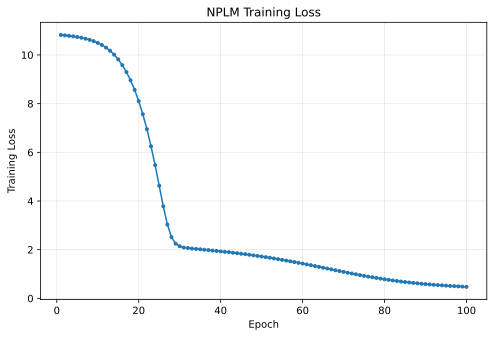

In [44]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# Example tokenizer; for teaching/demo this is convenient.
# Any tokenizer is fine as long as it returns integer ids.
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

text = """
the cat sat on the mat .
the dog sat on the rug .
the cat chased the dog .
the dog chased the cat .
"""

enc = tokenizer(text, add_special_tokens=False)
token_ids = enc["input_ids"]

context_size = 3
dataset = NPLMTextDataset(token_ids, context_size=context_size)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=64,
    hidden_dim=128,
    use_direct_connections=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 100
epoch_losses = []

model.train()
for epoch in tqdm(range(num_epochs)):
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

    avg_loss = total_loss / max(total_items, 1)
    epoch_losses.append(avg_loss)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NPLM Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

- **Inference the next token given the prompt**

In [45]:
model.eval()
prompt = "the cat sat"
prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]

# keep only last `context_size` tokens
context = prompt_ids[-context_size:]
if len(context) < context_size:
    context = [tokenizer.pad_token_id] * (context_size - len(context)) + context

print(context_size, context)
x = torch.tensor([context], dtype=torch.long).to(device)
top_probs, top_ids = model.predict_next(x, top_k=5)

for p, idx in zip(top_probs[0].tolist(), top_ids[0].tolist()):
    print(f"{tokenizer.decode([idx]).strip()!r}: {p:.4f}")

3 [1169, 3797, 3332]
'on': 0.6924
'the': 0.1509
'the': 0.0448
'': 0.0359
'cat': 0.0144


<a id=33></a>
#### 3.3 NPLM on wikitext dataset

In [46]:
from datasets import load_dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(ds["train"])

Dataset({
    features: ['text'],
    num_rows: 36718
})


In [47]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


Dataset({
    features: ['text'],
    num_rows: 36718
})


Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


Number of training documents: 23767
Number of training tokens: 2463182
Number of training examples: 2463179


Epoch 10/10: 100%|█████████████████████████████████████████████████████| 19244/19244 [01:16<00:00, 252.20it/s, loss=4.3426]


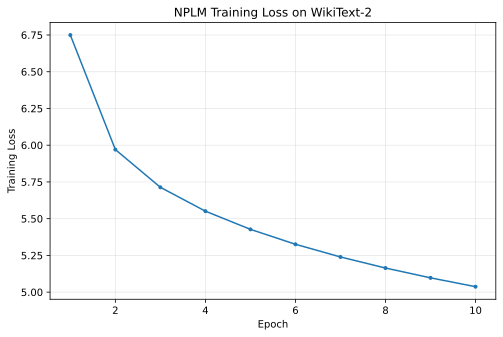

In [48]:
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(ds["train"])

# --------------------------------------------------
# 2. Tokenizer
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --------------------------------------------------
# 3. Convert the whole training split into token ids
#    We skip empty lines to reduce useless samples.
# --------------------------------------------------
train_texts = [x for x in ds["train"]["text"] if x.strip()]

# Join documents with eos token so boundaries are visible
full_text = f" {tokenizer.eos_token} ".join(train_texts)

enc = tokenizer(full_text, add_special_tokens=False)
token_ids = enc["input_ids"]

print(f"Number of training documents: {len(train_texts)}")
print(f"Number of training tokens: {len(token_ids)}")

# --------------------------------------------------
# 4. Build dataset / dataloader
# --------------------------------------------------
context_size = 3
dataset = NPLMTextDataset(token_ids, context_size=context_size)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Number of training examples: {len(dataset)}")

# --------------------------------------------------
# 5. Model config
# --------------------------------------------------
config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=64,
    hidden_dim=128,
    use_direct_connections=True,
)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# --------------------------------------------------
# 6. Training
# --------------------------------------------------
num_epochs = 10
epoch_losses = []

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    total_items = 0

    progress = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / max(total_items, 1)
    epoch_losses.append(avg_loss)

# --------------------------------------------------
# 7. Plot training loss
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NPLM Training Loss on WikiText-2")
plt.grid(True, alpha=0.3)
plt.show()

<a id=4></a>
### 4. LSTM

<a id=41></a>

#### 4.1 Pytorch LSTM

- This demo code is adopted from [Word Language Model](https://github.com/singlasahil14/word-language-model)
- Make the dataset ready

In [49]:
import os
from io import open
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

import torch
import time
import math
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt



EMSIZE = 200      # embedding size
NHID = 200        # hidden size
NLAYERS = 2       # number of LSTM layers
DROPOUT = 0.2
MODEL_TYPE = "LSTM"

EPOCHS = 10
BATCH_SIZE = 20
EVAL_BATCH_SIZE = 10
BPTT = 35
CLIP = 0.25
SEED = 17
SAVE_PATH = "model.pt"
LOG_INTERVAL = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
torch.manual_seed(SEED)

https://hf-mirror.com
Using device: cuda


In [50]:
# Load data from Hugging Face datasets

from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1") # Load dataset
tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True) # Tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def remove_empty(example): # Remove empty lines
    return example["text"] is not None and example["text"].strip() != ""

ds = ds.filter(remove_empty)

def tokenize_function(examples): # Tokenize
    return tokenizer(examples["text"])

tokenized_ds = ds.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

BLOCK_SIZE = 64   # or 128

def group_texts(examples):
    # Concatenate all examples
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated["input_ids"])

    # Drop remainder to make equal blocks
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE

    result = {
        k: [t[i:i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }

    # For custom LM training, labels are input_ids shifted later in train loop
    return result

def collate_lm(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])          # [B, T]
    attention_mask = torch.stack([x["attention_mask"] for x in batch])  # [B, T]
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
    }

lm_ds = tokenized_ds.map(group_texts, batched=True)

lm_ds.set_format(type="torch", columns=["input_ids", "attention_mask"])


train_loader = DataLoader(
    lm_ds["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_lm,
)

val_loader = DataLoader(
    lm_ds["validation"],
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_lm,
)

test_loader = DataLoader(
    lm_ds["test"],
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_lm,
)

In [51]:
from tqdm.auto import tqdm
import math

def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for batch in progress:
        input_ids = batch["input_ids"].to(DEVICE)   # [B, T]

        x = input_ids[:, :-1].t().contiguous()      # [T-1, B]
        y = input_ids[:, 1:].t().contiguous().reshape(-1)   # [(T-1)*B]

        hidden = model.init_hidden(x.size(1))
        optimizer.zero_grad()

        output, hidden = model(x, hidden)
        loss = criterion(output, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.2f}", ppl=f"{math.exp(loss.item()):.2f}")

    return total_loss / len(train_loader)

In [52]:
def evaluate(loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)

            x = input_ids[:, :-1].t().contiguous()
            y = input_ids[:, 1:].t().contiguous().reshape(-1)

            hidden = model.init_hidden(x.size(1))
            output, hidden = model(x, hidden)
            loss = criterion(output, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [53]:
class RNNModel(nn.Module):
    """Container module with an encoder, a recurrent module, and a decoder."""

    def __init__(self, rnn_type, ntoken, ninp, nhid, nlayers, dropout=0.5, tie_weights=False):
        super(RNNModel, self).__init__()
        self.ntoken = ntoken
        self.drop = nn.Dropout(dropout)
        self.encoder = nn.Embedding(ntoken, ninp)
        if rnn_type in ['LSTM', 'GRU']:
            self.rnn = getattr(nn, rnn_type)(ninp, nhid, nlayers, dropout=dropout)
        else:
            try:
                nonlinearity = {'RNN_TANH': 'tanh', 'RNN_RELU': 'relu'}[rnn_type]
            except KeyError as e:
                raise ValueError( """An invalid option for `--model` was supplied,
                                 options are ['LSTM', 'GRU', 'RNN_TANH' or 'RNN_RELU']""") from e
            self.rnn = nn.RNN(ninp, nhid, nlayers, nonlinearity=nonlinearity, dropout=dropout)
        self.decoder = nn.Linear(nhid, ntoken)

        # Optionally tie weights as in:
        # "Using the Output Embedding to Improve Language Models" (Press & Wolf 2016)
        # https://arxiv.org/abs/1608.05859
        # and
        # "Tying Word Vectors and Word Classifiers: A Loss Framework for Language Modeling" (Inan et al. 2016)
        # https://arxiv.org/abs/1611.01462
        if tie_weights:
            if nhid != ninp:
                raise ValueError('When using the tied flag, nhid must be equal to emsize')
            self.decoder.weight = self.encoder.weight

        self.init_weights()

        self.rnn_type = rnn_type
        self.nhid = nhid
        self.nlayers = nlayers

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.encoder.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def forward(self, input, hidden):
        emb = self.drop(self.encoder(input))
        output, hidden = self.rnn(emb, hidden)
        output = self.drop(output)
        decoded = self.decoder(output)
        decoded = decoded.view(-1, self.ntoken)
        return F.log_softmax(decoded, dim=1), hidden

    def init_hidden(self, bsz):
        weight = next(self.parameters())
        if self.rnn_type == 'LSTM':
            return (weight.new_zeros(self.nlayers, bsz, self.nhid),
                    weight.new_zeros(self.nlayers, bsz, self.nhid))
        else:
            return weight.new_zeros(self.nlayers, bsz, self.nhid)

In [54]:
# Helper functions
def repackage_hidden(h):
    if isinstance(h, torch.Tensor):
        return h.detach()
    return tuple(repackage_hidden(v) for v in h)

def get_batch(source, i):
    seq_len = min(BPTT, len(source) - 1 - i)
    data_batch = source[i:i + seq_len]
    target_batch = source[i + 1:i + 1 + seq_len].reshape(-1)
    return data_batch, target_batch
    

<a id=42> </a>

#### 4.2 Training LSTM

In [55]:
# Main training loop

ntokens = len(tokenizer)
print(ntokens, tokenizer.vocab_size)
model = RNNModel(
    MODEL_TYPE,
    len(tokenizer),
    EMSIZE,
    NHID,
    NLAYERS,
    DROPOUT,
).to(DEVICE)

criterion = nn.NLLLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

best_val_loss = None

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    train_loss = train_one_epoch(epoch)
    val_loss = evaluate(val_loader)

    print("-" * 89)
    print(
        f"| end of epoch {epoch:3d} | time: {time.time() - epoch_start_time:5.2f}s "
        f"| train loss {train_loss:5.2f} | train ppl {math.exp(train_loss):8.2f} "
        f"| valid loss {val_loss:5.2f} | valid ppl {math.exp(val_loss):8.2f}"
    )
    print("-" * 89)

    if best_val_loss is None or val_loss < best_val_loss:
        torch.save(model, SAVE_PATH)
        best_val_loss = val_loss

50257 50257


Epoch 1/10:   0%|          | 0/1869 [00:00<?, ?it/s]

-----------------------------------------------------------------------------------------
| end of epoch   1 | time: 26.08s | train loss  7.33 | train ppl  1521.00 | valid loss  6.88 | valid ppl   971.38
-----------------------------------------------------------------------------------------


Epoch 2/10:   0%|          | 0/1869 [00:00<?, ?it/s]

-----------------------------------------------------------------------------------------
| end of epoch   2 | time: 26.58s | train loss  6.65 | train ppl   772.94 | valid loss  6.54 | valid ppl   693.39
-----------------------------------------------------------------------------------------


...

-----------------------------------------------------------------------------------------
| end of epoch   8 | time: 25.80s | train loss  5.56 | train ppl   258.55 | valid loss  5.84 | valid ppl   343.84
-----------------------------------------------------------------------------------------


Epoch 9/10:   0%|          | 0/1869 [00:00<?, ?it/s]

-----------------------------------------------------------------------------------------
| end of epoch   9 | time: 25.47s | train loss  5.45 | train ppl   232.36 | valid loss  5.80 | valid ppl   328.92
-----------------------------------------------------------------------------------------


Epoch 10/10:   0%|          | 0/1869 [00:00<?, ?it/s]

-----------------------------------------------------------------------------------------
| end of epoch  10 | time: 25.18s | train loss  5.36 | train ppl   212.05 | valid loss  5.76 | valid ppl   317.88
-----------------------------------------------------------------------------------------


In [56]:
model = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False).to(DEVICE)
model.rnn.flatten_parameters()

test_loss = evaluate(test_loader)

print("=" * 89)
print(f"| End of training | test loss {test_loss:5.2f} | test ppl {math.exp(test_loss):8.2f}")
print("=" * 89)

| End of training | test loss  5.79 | test ppl   326.16


In [57]:
model = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False).to(DEVICE)
model.eval()
model.rnn.flatten_parameters()

def sample_text(prompt="The", max_new_tokens=100, temperature=1.0):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)   # [1, T]
    x = input_ids.t().contiguous()   # [T, 1]

    hidden = model.init_hidden(1)
    generated = input_ids[0].tolist()

    with torch.no_grad():
        if x.size(0) > 1:
            _, hidden = model(x[:-1], hidden)

        current_input = x[-1:].contiguous()

        for _ in range(max_new_tokens):
            output, hidden = model(current_input, hidden)
            probs = torch.exp(output.squeeze(0) / temperature).cpu()
            next_token = torch.multinomial(probs, 1).item()

            generated.append(next_token)
            current_input = torch.tensor([[next_token]], dtype=torch.long, device=DEVICE)

    return tokenizer.decode(generated, skip_special_tokens=True)

print(sample_text("The meaning of life is", max_new_tokens=80, temperature=1.0))

The meaning of life is frequent from the public infringement as the corrected releases . Ent attributed to a site statues for the feeling , without the little agents of birth his next release heactials on the entry in southeastern rock . He described the musical politicians , albeit considered up by that in the point of the grand succeeded environmentalists . In doing Olivier , Peel rejects Alan el Calats 's score to Bramhes and this would say about


In [58]:
# Finally, you all done! Please submit your jupyter notebook via elearning!
import time
your_chinese_name = "罗俊昊" # put your chinese name here
your_student_id = "23307130030" # put your student id here

jnk_end_time = time.time()
total = jnk_end_time - jnk_start_time
h, rem = divmod(int(total), 3600)
m, s = divmod(rem, 60)

print(f"Total runtime: {h} h {m} min {s} s")
print(f"I am {your_chinese_name}:{your_student_id}, I am doing a great job!")

Total runtime: 0 h 37 min 46 s
I am 罗俊昊:23307130030, I am doing a great job!


- **Save your jupyter notebook as a html file**

To save your notebook as pdf you can use the following command

<div style="background:#f6f6f6; padding:6px 10px; border-radius:10px;"><pre style="margin:0; padding:0; background:transparent; line-height:1.2;"><code style="background:transparent; color:#000; padding:0; display:block;">jupyter nbconvert lecture-04-neural-lms.ipynb --to html --template classic --embed-images</code></pre>
</div>

In [59]:
!jupyter nbconvert lecture-04-neural-lms-23307130030-LuoJunHao.ipynb --to html --template classic --embed-images

[NbConvertApp] Converting notebook lecture-04-neural-lms-23307130030-LuoJunHao.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 608825 bytes to lecture-04-neural-lms-23307130030-LuoJunHao.html
